In [5]:
%pip install pandas
%pip install prophet
%pip install matplotlib
%pip install scikit-learn
%pip install --upgrade mplfinance

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf

from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', None)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv('Electricity Dataset.csv', sep=';', decimal=',')
df = df.rename(columns={'Unnamed: 0': 'Timestamp'})
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values(by='Timestamp', ascending=True)

display(df)

,Timestamp,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,MT_011,MT_012,MT_013,MT_014,MT_015,MT_016,MT_017,MT_018,MT_019,MT_020,MT_021,MT_022,MT_023,MT_024,MT_025,MT_026,MT_027,MT_028,MT_029,MT_030,MT_031,MT_032,MT_033,MT_034,MT_035,MT_036,MT_037,MT_038,MT_039,MT_040,MT_041,MT_042,MT_043,MT_044,MT_045,MT_046,MT_047,MT_048,MT_049,MT_050,MT_051,MT_052,MT_053,MT_054,MT_055,MT_056,MT_057,MT_058,MT_059,MT_060,MT_061,MT_062,MT_063,MT_064,MT_065,MT_066,MT_067,MT_068,MT_069,MT_070,MT_071,MT_072,MT_073,MT_074,MT_075,MT_076,MT_077,MT_078,MT_079,MT_080,MT_081,MT_082,MT_083,MT_084,MT_085,MT_086,MT_087,MT_088,MT_089,MT_090,MT_091,MT_092,MT_093,MT_094,MT_095,MT_096,MT_097,MT_098,MT_099,MT_100,MT_101,MT_102,MT_103,MT_104,MT_105,MT_106,MT_107,MT_108,MT_109,MT_110,MT_111,MT_112,MT_113,MT_114,MT_115,MT_116,MT_117,MT_118,MT_119,MT_120,MT_121,MT_122,MT_123,MT_124,MT_125,MT_126,MT_127,MT_128,MT_129,MT_130,MT_131,MT_132,MT_133,MT_134,MT_135,MT_136,MT_137,MT_138,MT_139,MT_140,MT_141,MT_142,MT_143,MT_144,MT_145,MT_146,MT_147,MT_148,MT_149,MT_150,MT_151,MT_152,MT_153,MT_154,MT_155,MT_156,MT_157,MT_158,MT_159,MT_160,MT_161,MT_162,MT_163,MT_164,MT_165,MT_166,MT_167,MT_168,MT_169,MT_170,MT_171,MT_172,MT_173,MT_174,MT_175,MT_176,MT_177,MT_178,MT_179,MT_180,MT_181,MT_182,MT_183,MT_184,MT_185,MT_186,MT_187,MT_188,MT_189,MT_190,MT_191,MT_192,MT_193,MT_194,MT_195,MT_196,MT_197,MT_198,MT_199,MT_200,MT_201,MT_202,MT_203,MT_204,MT_205,MT_206,MT_207,MT_208,MT_209,MT_210,MT_211,MT_212,MT_213,MT_214,MT_215,MT_216,MT_217,MT_218,MT_219,MT_220,MT_221,MT_222,MT_223,MT_224,MT_225,MT_226,MT_227,MT_228,MT_229,MT_230,MT_231,MT_232,MT_233,MT_234,MT_235,MT_236,MT_237,MT_238,MT_239,MT_240,MT_241,MT_242,MT_243,MT_244,MT_245,MT_246,MT_247,MT_248,MT_249,MT_250,MT_251,MT_252,MT_253,MT_254,MT_255,MT_256,MT_257,MT_258,MT_259,MT_260,MT_261,MT_262,MT_263,MT_264,MT_265,MT_266,MT_267,MT_268,MT_269,MT_270,MT_271,MT_272,MT_273,MT_274,MT_275,MT_276,MT_277,MT_278,MT_279,MT_280,MT_281,MT_282,MT_283,MT_284,MT_285,MT_286,MT_287,MT_288,MT_289,MT_290,MT_291,MT_292,MT_293,MT_294,MT_295,MT_296,MT_297,MT_298,MT_299,MT_300,MT_301,MT_302,MT_303,MT_304,MT_305,MT_306,MT_307,MT_308,MT_309,MT_310,MT_311,MT_312,MT_313,MT_314,MT_315,MT_316,MT_317,MT_318,MT_319,MT_320,MT_321,MT_322,MT_323,MT_324,MT_325,MT_326,MT_327,MT_328,MT_329,MT_330,MT_331,MT_332,MT_333,MT_334,MT_335,MT_336,MT_337,MT_338,MT_339,MT_340,MT_341,MT_342,MT_343,MT_344,MT_345,MT_346,MT_347,MT_348,MT_349,MT_350,MT_351,MT_352,MT_353,MT_354,MT_355,MT_356,MT_357,MT_358,MT_359,MT_360,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
0,2011-01-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,71.770335,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,260.416667,45.721750,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000

## Luca's Prophet Implementation ':\)'

16:14:39 - cmdstanpy - INFO - Chain [1] start processing
16:15:17 - cmdstanpy - INFO - Chain [1] done processing


MAPE for MT_001: 101.39%
MAE:  1.94 kW
RMSE: 2.16 kW


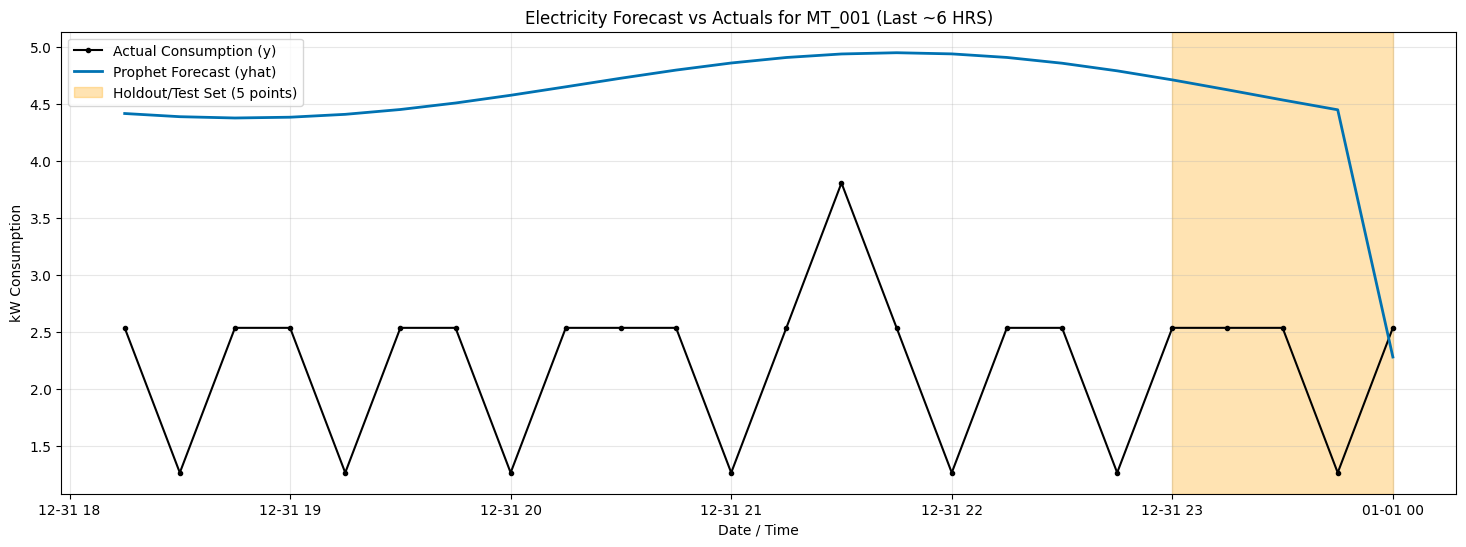

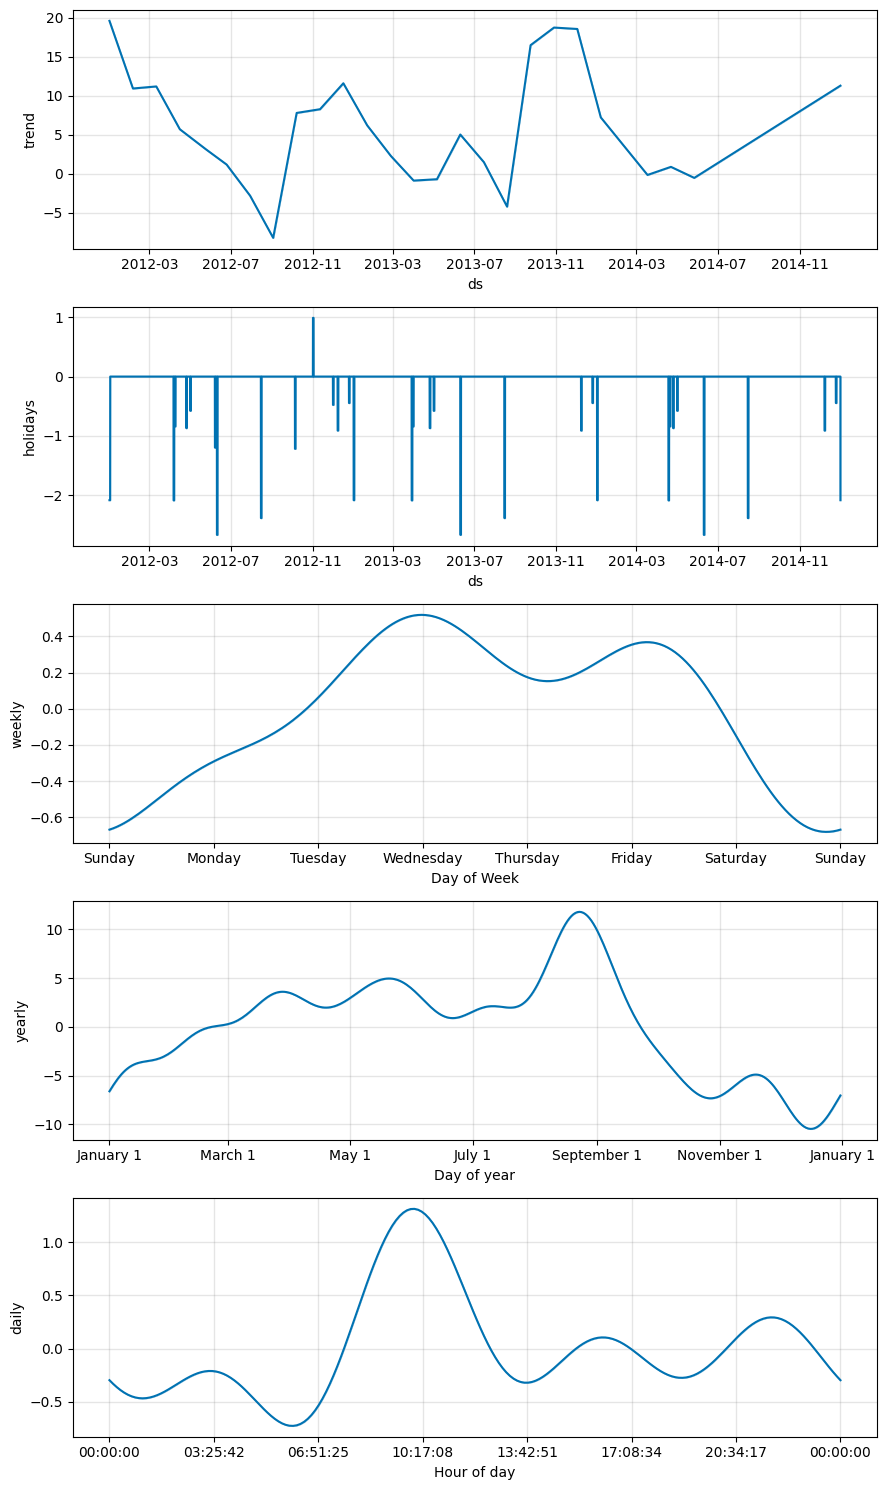

In [6]:
# ---------------------------------------------------------
# 1. Data Prep
# ---------------------------------------------------------
client_id = 'MT_001'
demo_client = df[['Timestamp', client_id]].copy()
demo_client = demo_client.rename(columns={'Timestamp': 'ds', client_id: 'y'})

client_ts = demo_client.set_index('ds')

first_non_zero_idx = demo_client[demo_client['y'] > 0].index.min()
demo_client = demo_client.loc[first_non_zero_idx:].reset_index(drop=True)

# ---------------------------------------------------------
# 2. Time Series Split (Holdout Set)
# ---------------------------------------------------------
train_df = demo_client.iloc[:-5]
test_df = demo_client.iloc[-5:]

# ---------------------------------------------------------
# 3. Model Training & Forecasting
# ---------------------------------------------------------
# Initialize Prophet and add Portugal national holidays
m = Prophet()
m.add_country_holidays(country_name='PT') 

# Fit the model on the training data ONLY
m.fit(train_df)

# Create future dataframe for 5 periods. 
future = m.make_future_dataframe(periods=5, freq='15min') 
forecast = m.predict(future)

# ---------------------------------------------------------
# 4. Evaluation (MAPE)
# ---------------------------------------------------------
# Extract the actuals and the predictions for just those final 5 points
y_true = test_df['y'].values
y_pred = forecast['yhat'].iloc[-5:].values

mape = mean_absolute_percentage_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"MAPE for {client_id}: {mape:.2%}")
print(f"MAE:  {mae:.2f} kW")
print(f"RMSE: {rmse:.2f} kW")


# ---------------------------------------------------------
# 5. Visualizations
# ---------------------------------------------------------
zoom_idx = -24

plt.figure(figsize=(18, 6))

# Plot the real data (Train + Test)
plt.plot(demo_client['ds'].iloc[zoom_idx:], demo_client['y'].iloc[zoom_idx:], 
         label='Actual Consumption (y)', color='black', marker='.', linestyle='-')

# Plot the Prophet forecast
plt.plot(forecast['ds'].iloc[zoom_idx:], forecast['yhat'].iloc[zoom_idx:], 
         label='Prophet Forecast (yhat)', color='#0072B2', linewidth=2)

# Highlight the 5-point holdout area in orange
plt.axvspan(test_df['ds'].iloc[0], test_df['ds'].iloc[-1], 
            color='orange', alpha=0.3, label='Holdout/Test Set (5 points)')

plt.title(f'Electricity Forecast vs Actuals for {client_id} (Last ~6 HRS)')
plt.xlabel('Date / Time')
plt.ylabel('kW Consumption')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# PLOT B: Prophet Components (Trend, Holidays, Seasonalities)
fig_components = m.plot_components(forecast)
plt.show()